In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from keras.applications.mobilenet import MobileNet, preprocess_input
from keras.layers import Flatten, Dense, GlobalAveragePooling2D, Dropout
from keras.models import Model
from keras.losses import categorical_crossentropy
from sklearn.metrics import classification_report, confusion_matrix

## Build Model

In [ ]:
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# Freeze backbone
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(units=7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


In [5]:
from tensorflow.keras.optimizers import Adam
for layer in base_model.layers[-30:]:
    layer.trainable = True
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Get data and Data Preparation

In [6]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("ananthu017/emotion-detection-fer")

# print("Path to dataset files:", path)

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)



train_data = train_datagen.flow_from_directory(
    directory=r"./ananthu017/emotion-detection-fer/versions/1/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

print(train_data.class_indices)   # dictionary of class labels
print("Total images found:", train_data.samples)

Found 28709 images belonging to 7 classes.
{'angry': 0, 'disgusted': 1, 'fearful': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprised': 6}
Total images found: 28709


In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weights = dict(enumerate(class_weights))

In [9]:
class_weights

{0: np.float64(1.0266046844269623),
 1: np.float64(9.406618610747051),
 2: np.float64(1.0010460615781582),
 3: np.float64(0.5684387684387684),
 4: np.float64(0.8260394187886635),
 5: np.float64(0.8491274770777877),
 6: np.float64(1.293372978330405)}

In [10]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_data = val_datagen.flow_from_directory(
    directory=r"./ananthu017/emotion-detection-fer/versions/1/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7178 images belonging to 7 classes.


In [11]:
print("Train classes:", train_data.class_indices)
print("Validation classes:", val_data.class_indices)

print("Train samples:", train_data.samples)
print("Validation samples:", val_data.samples)

Train classes: {'angry': 0, 'disgusted': 1, 'fearful': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprised': 6}
Validation classes: {'angry': 0, 'disgusted': 1, 'fearful': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprised': 6}
Train samples: 28709
Validation samples: 7178


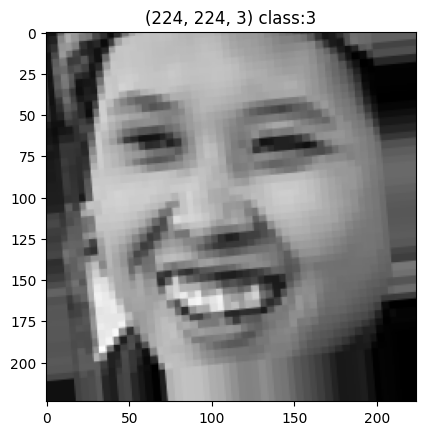

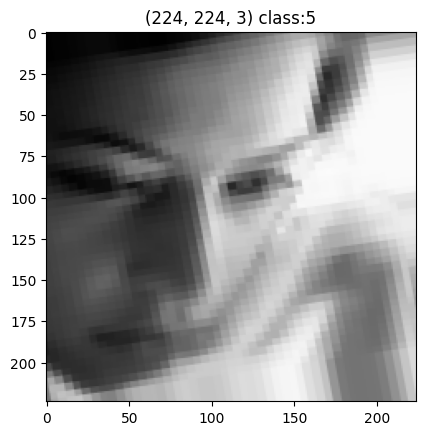

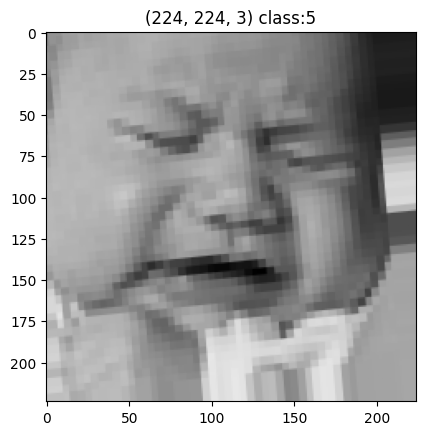

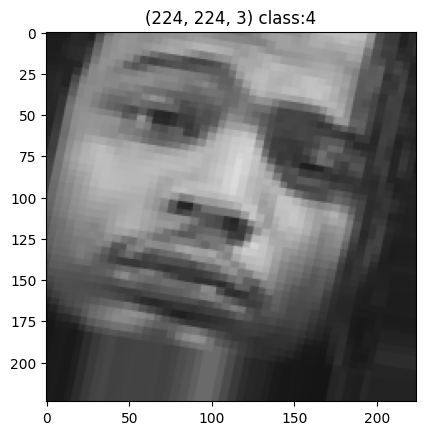

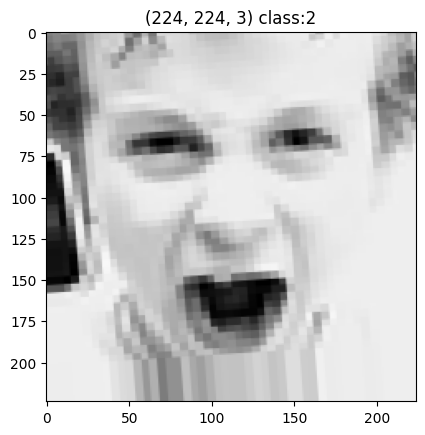

In [12]:
t_img, label = next(train_data)


def plotImages(img_arr, label):
  """
  input  :- images array 
  output :- plots the images 
  """
  count = 0
  for im, l in zip(img_arr,label) :
    # print(im.shape, l)
    plt.imshow(im)
    plt.title(f"{im.shape} class:{np.argmax(l)}")
    plt.axis = False
    plt.show()
    
    count += 1
    if count == 5:
      break


plotImages(t_img, label)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

es = EarlyStopping(
    monitor='val_loss',          # smoother signal
    min_delta=0.01,             # tiny improvement counts
    patience=10,                 # give model time
    verbose=1,
    restore_best_weights=True
)

m_ch = ModelCheckpoint(
    filepath="best_model.h5",
    monitor='val_loss',
    verbose=1,
    save_best_only=True
)

callbacks = [es, m_ch]

In [14]:
import os

# Use the first GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [15]:
hist = model.fit(
    train_data,
    steps_per_epoch=20,
    epochs=50,
    validation_data=val_data,
    validation_steps=8,
    callbacks=[es, m_ch]
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.2159 - loss: 2.3581
Epoch 1: val_loss improved from None to 2.66815, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 749ms/step - accuracy: 0.2203 - loss: 2.2960 - val_accuracy: 0.0117 - val_loss: 2.6682
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.2066 - loss: 2.1133
Epoch 2: val_loss did not improve from 2.66815
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 736ms/step - accuracy: 0.2266 - loss: 2.0466 - val_accuracy: 0.0039 - val_loss: 3.3544
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.3013 - loss: 1.8272
Epoch 3: val_loss did not improve from 2.66815
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 693ms/step - accuracy: 0.2828 - loss: 1.8464 - val_accuracy: 0.0117 - val_loss: 2.9077
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.2912 - loss: 1.8060
Epoch 4: val_loss did not improve from 2.66815
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 732ms/step - accuracy: 0.3047 - loss: 1.7960 - val_accuracy: 0.0156 - val_loss: 2.7408
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.3565 - loss: 1


Epoch 5: finished saving model to best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 722ms/step - accuracy: 0.3719 - loss: 1.6687 - val_accuracy: 0.0547 - val_loss: 2.3521
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.3313 - loss: 1.7057
Epoch 6: val_loss did not improve from 2.35213
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 710ms/step - accuracy: 0.3359 - loss: 1.7043 - val_accuracy: 0.0312 - val_loss: 2.5854
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.4046 - loss: 1.5842
Epoch 7: val_loss improved from 2.35213 to 1.99866, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 688ms/step - accuracy: 0.4016 - loss: 1.5986 - val_accuracy: 0.1289 - val_loss: 1.9987
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.3855 - loss: 1.5941
Epoch 8: val_loss improved from 1.99866 to 1.78551, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 666ms/step - accuracy: 0.3953 - loss: 1.5929 - val_accuracy: 0.2539 - val_loss: 1.7855
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.3811 - loss: 1.5548
Epoch 9: val_loss improved from 1.78551 to 1.77364, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 652ms/step - accuracy: 0.3984 - loss: 1.5405 - val_accuracy: 0.2344 - val_loss: 1.7736
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.4456 - loss: 1.4799
Epoch 10: val_loss improved from 1.77364 to 1.70907, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 680ms/step - accuracy: 0.4500 - loss: 1.4674 - val_accuracy: 0.2422 - val_loss: 1.7091
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.4082 - loss: 1.5306
Epoch 11: val_loss improved from 1.70907 to 1.42833, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 657ms/step - accuracy: 0.4062 - loss: 1.5221 - val_accuracy: 0.4648 - val_loss: 1.4283
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.4719 - loss: 1.4775
Epoch 12: val_loss did not improve from 1.42833
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 645ms/step - accuracy: 0.4531 - loss: 1.4776 - val_accuracy: 0.4102 - val_loss: 1.5107
Epoch 13/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.4320 - loss: 1.4543
Epoch 13: val_loss did not improve from 1.42833
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 721ms/step - accuracy: 0.4469 - loss: 1.4345 - val_accuracy: 0.4570 - val_loss: 1.4362
Epoch 14/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.4428 - loss: 1.4315
Epoch 14: val_loss improved from 1.42833 to 1.31656, saving model to best_model.h5



Epoch 14: finished saving model to best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 678ms/step - accuracy: 0.4391 - loss: 1.4447 - val_accuracy: 0.4922 - val_loss: 1.3166
Epoch 15/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.4158 - loss: 1.4187
Epoch 15: val_loss did not improve from 1.31656
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 675ms/step - accuracy: 0.4469 - loss: 1.3941 - val_accuracy: 0.2969 - val_loss: 1.6467
Epoch 16/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.4637 - loss: 1.3963
Epoch 16: val_loss did not improve from 1.31656
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 727ms/step - accuracy: 0.4547 - loss: 1.3874 - val_accuracy: 0.4023 - val_loss: 1.4789
Epoch 17/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.4495 - loss: 1.4169
Epoch 17: val_loss did not improve from 1.31656
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 723ms/step - accuracy: 0.4391 - loss: 1.4585 - val_accuracy: 0.3203 - val_loss: 1.5850
Epoch 18/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.4484 -


Epoch 18: finished saving model to best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 698ms/step - accuracy: 0.4609 - loss: 1.4417 - val_accuracy: 0.5000 - val_loss: 1.2941
Epoch 19/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.4415 - loss: 1.4280
Epoch 19: val_loss did not improve from 1.29409
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 796ms/step - accuracy: 0.4719 - loss: 1.3995 - val_accuracy: 0.3750 - val_loss: 1.4988
Epoch 20/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.4911 - loss: 1.3465
Epoch 20: val_loss did not improve from 1.29409
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 724ms/step - accuracy: 0.4656 - loss: 1.3773 - val_accuracy: 0.3633 - val_loss: 1.5155
Epoch 21/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.4780 - loss: 1.4110
Epoch 21: val_loss did not improve from 1.29409
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 715ms/step - accuracy: 0.4875 - loss: 1.3734 - val_accuracy: 0.3008 - val_loss: 1.7018
Epoch 22/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.5039 -

In [16]:
from keras.models import load_model
model=load_model("model/best_model.h5")

In [17]:
his=hist.history
his.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

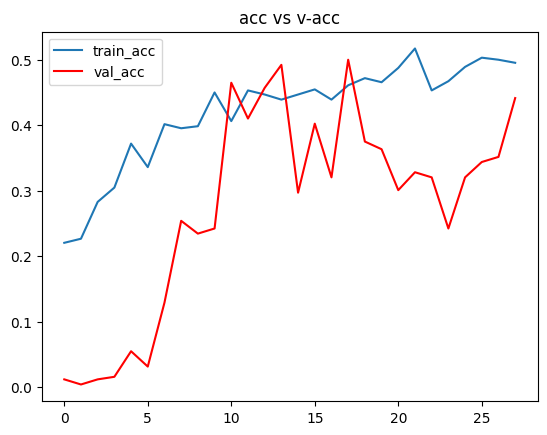

In [21]:
plt.plot(his['accuracy'])
plt.plot(his['val_accuracy'] , c = "red")
plt.title("acc vs v-acc")
plt.legend(['train_acc', 'val_acc'])
plt.show()

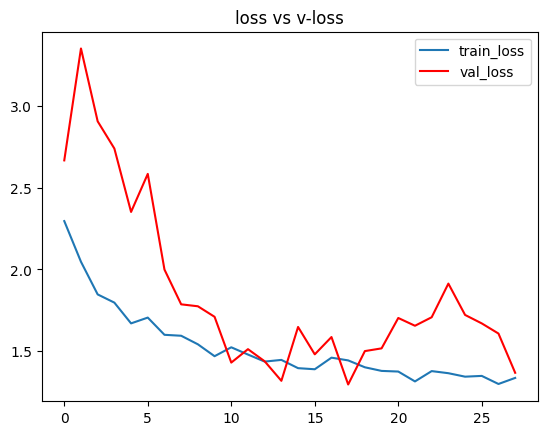

In [22]:
plt.plot(his['loss'])
plt.plot(his['val_loss'] , c = "red")
plt.title("loss vs v-loss")
plt.legend(['train_loss', 'val_loss'])
plt.show()

In [23]:
op=dict(zip( train_data.class_indices.values(), train_data.class_indices.keys()))
op

{0: 'angry',
 1: 'disgusted',
 2: 'fearful',
 3: 'happy',
 4: 'neutral',
 5: 'sad',
 6: 'surprised'}

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 825ms/step
 the image is of fearful


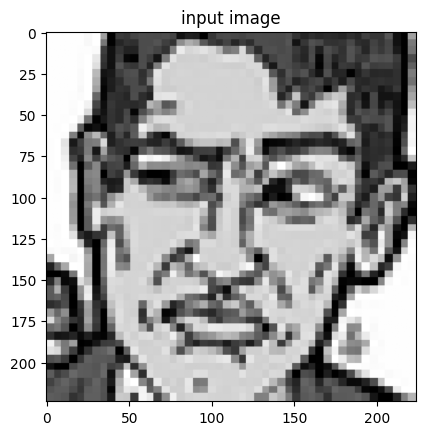

In [24]:
path=r"ananthu017/emotion-detection-fer/versions/1/test/angry/im0.png"
img = load_img(path, target_size=(224,224) )

i = img_to_array(img)/255
input_arr = np.array([i])
input_arr.shape

pred = np.argmax(model.predict(input_arr))

print(f" the image is of {op[pred]}")

# to display the image  
plt.imshow(input_arr[0])
plt.title("input image")
plt.show()